In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
property_data = pd.read_csv(
    "../data/processed/property_intelligence.csv"
)

print("Dataset loaded successfully")
print("Dataset shape:", property_data.shape)

property_data.head()

Dataset loaded successfully
Dataset shape: (51767, 22)


,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,...,latitude,longitude,predicted_price,price_difference,price_difference_percent,predicted_price_per_sqft,price_per_sqft_difference,anomaly_label,anomaly_score,is_anomaly
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,...,19.244410,73.123253,5.749573e+06,8.507096e+05,14.796047,7595.209299,1123.790701,1,0.261409,False
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,...,19.257294,73.148872,6.422073e+06,-2.522321e+05,-3.927581,9849.805444,-386.859125,1,0.257219,False
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,...,19.209026,73.081276,4.378319e+06,2.216174e+05,5.061702,11056.360025,559.639975,1,0.242774,False
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,...,19.097841,72.851158,5.084753e+07,1.132471e+06,2.227190,44997.813310,1002.186690,1,0.214435,False
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,...,19.420601,72.809319,3.663747e+06,2.512535e+05,6.857829,8422.405793,577.594207,1,0.208075,False


In [4]:
print("Available columns:")

for column in property_data.columns:
    print(column)

Available columns:
price
area
price_per_sqft
locality
city
property_type
bedroom_num
bathroom_num
balcony_num
furnished
age
total_floors
latitude
longitude
predicted_price
price_difference
price_difference_percent
predicted_price_per_sqft
price_per_sqft_difference
anomaly_label
anomaly_score
is_anomaly


In [5]:
model = joblib.load(
    "../models/best_tuned_model.joblib"
)

preprocessor = joblib.load(
    "../models/preprocessor.joblib"
)

print("Model loaded successfully")
print("Preprocessor loaded successfully")

print("\nModel type:")
print(type(model))


Model loaded successfully
Preprocessor loaded successfully

Model type:
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [6]:
df = property_data.copy()

print("Working copy created")
print("Shape:", df.shape)

Working copy created
Shape: (51767, 22)


In [7]:
# Area per bedroom
df["area_per_bedroom"] = (
    df["area"] /
    df["bedroom_num"].replace(0, np.nan)
)

# Bathroom per bedroom
df["bathroom_per_bedroom"] = (
    df["bathroom_num"] /
    df["bedroom_num"].replace(0, np.nan)
)

# Age group
def create_age_group(age):
    if pd.isna(age):
        return "Unknown"
    elif age <= 5:
        return "New"
    elif age <= 15:
        return "Moderately New"
    elif age <= 30:
        return "Old"
    else:
        return "Very Old"

df["age_group"] = df["age"].apply(
    create_age_group
)

print("Feature engineering completed")

Feature engineering completed


In [8]:
X = df.drop(
    columns=[
        "price",
        "price_per_sqft"
    ],
    errors="ignore"
)

print("X shape:", X.shape)
print("Features:")
print(X.columns.tolist())

X shape: (51767, 23)
Features:
['area', 'locality', 'city', 'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors', 'latitude', 'longitude', 'predicted_price', 'price_difference', 'price_difference_percent', 'predicted_price_per_sqft', 'price_per_sqft_difference', 'anomaly_label', 'anomaly_score', 'is_anomaly', 'area_per_bedroom', 'bathroom_per_bedroom', 'age_group']


In [9]:
if "city" in X.columns:

    if X["city"].nunique() <= 1:
        X = X.drop(columns=["city"])

print("Final X shape:", X.shape)

Final X shape: (51767, 23)


In [10]:
X_processed = preprocessor.transform(X)

print("Data transformed successfully")
print("Processed data shape:", X_processed.shape)

Data transformed successfully
Processed data shape: (51767, 112)


In [11]:
feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:")
print(len(feature_names))

Number of transformed features:
112


In [12]:
if hasattr(X_processed, "toarray"):
    X_processed_array = X_processed.toarray()
else:
    X_processed_array = X_processed

X_processed_df = pd.DataFrame(
    X_processed_array,
    columns=feature_names
)

print("Processed DataFrame created")
print("Shape:", X_processed_df.shape)

X_processed_df.head()

Processed DataFrame created
Shape: (51767, 112)


,num__area,num__bedroom_num,num__bathroom_num,num__balcony_num,num__age,num__total_floors,num__latitude,num__longitude,num__area_per_bedroom,num__bathroom_per_bedroom,...,cat__property_type_Independent House,cat__property_type_Villa,cat__property_type_infrequent_sklearn,cat__furnished_Furnished,cat__furnished_Semi-Furnished,cat__furnished_Unfurnished,cat__age_group_Moderately New,cat__age_group_New,cat__age_group_Old,cat__age_group_Very Old
0,-0.324915,-0.002192,-0.116667,-0.277509,-0.541006,-0.012307,0.122770,0.323714,-0.734198,-0.333726,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-0.481270,-0.002192,-0.116667,-0.277509,-0.541006,-0.012307,0.145213,0.377113,-1.073570,-0.333726,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-0.862479,-1.069934,-1.267309,-0.277509,-0.541006,-0.012307,0.061137,0.236221,-0.621073,-0.333726,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.230517,1.065551,1.033975,-0.277509,-0.541006,-0.012307,-0.132534,-0.243416,-0.746049,-0.333726,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,-0.804404,-1.069934,-1.267309,-0.277509,-0.541006,-0.012307,0.429674,-0.330623,-0.368968,-0.333726,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [13]:
SHAP_SAMPLE_SIZE = min(
    50,
    len(X_processed_df)
)

X_shap = X_processed_df.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

print("SHAP sample created")
print("SHAP sample shape:", X_shap.shape)

SHAP sample created
SHAP sample shape: (50, 112)


In [14]:
BACKGROUND_SIZE = min(
    20,
    len(X_processed_df)
)

X_background = X_processed_df.sample(
    n=BACKGROUND_SIZE,
    random_state=42
)

print("Background dataset created")
print("Background shape:", X_background.shape)

Background dataset created
Background shape: (20, 112)


In [15]:
# Create a TreeExplainer specifically for Random Forest

explainer = shap.TreeExplainer(model)

print("Random Forest SHAP TreeExplainer created successfully")

Random Forest SHAP TreeExplainer created successfully


In [16]:
# Calculate SHAP values for only 10 properties

X_shap_small = X_shap.iloc[:10].copy()

print("Calculating SHAP values...")
print("Properties:", len(X_shap_small))
print("Features:", X_shap_small.shape[1])

shap_values = explainer.shap_values(
    X_shap_small
)

print("SHAP values calculated successfully")
print("SHAP values shape:", np.array(shap_values).shape)

Calculating SHAP values...
Properties: 10
Features: 112
SHAP values calculated successfully
SHAP values shape: (10, 112)


In [17]:
print("SHAP calculation completed")
print("SHAP values shape:", np.array(shap_values).shape)

SHAP calculation completed
SHAP values shape: (10, 112)


In [18]:
shap_values_array = np.array(shap_values)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap_value": np.abs(shap_values_array).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap_value",
    ascending=False
).reset_index(drop=True)

shap_importance.head(20)

,feature,mean_abs_shap_value
0,num__longitude,7.453347e+06
1,num__latitude,5.530193e+06
2,num__bedroom_num,4.139833e+06
3,num__area,2.706845e+06
4,num__area_per_bedroom,8.120480e+05
5,num__balcony_num,5.541608e+05
6,num__age,1.711971e+05
7,cat__city_Mumbai,1.145216e+05
8,cat__locality_Powai,1.032105e+05
9,cat__furnished_Furnished,1.022851e+05


In [19]:
top_15 = shap_importance.head(15)

print("Top 15 Features Affecting House Price Prediction:\n")

display(top_15)

Top 15 Features Affecting House Price Prediction:



,feature,mean_abs_shap_value
0,num__longitude,7.453347e+06
1,num__latitude,5.530193e+06
2,num__bedroom_num,4.139833e+06
3,num__area,2.706845e+06
4,num__area_per_bedroom,8.120480e+05
5,num__balcony_num,5.541608e+05
6,num__age,1.711971e+05
7,cat__city_Mumbai,1.145216e+05
8,cat__locality_Powai,1.032105e+05
9,cat__furnished_Furnished,1.022851e+05


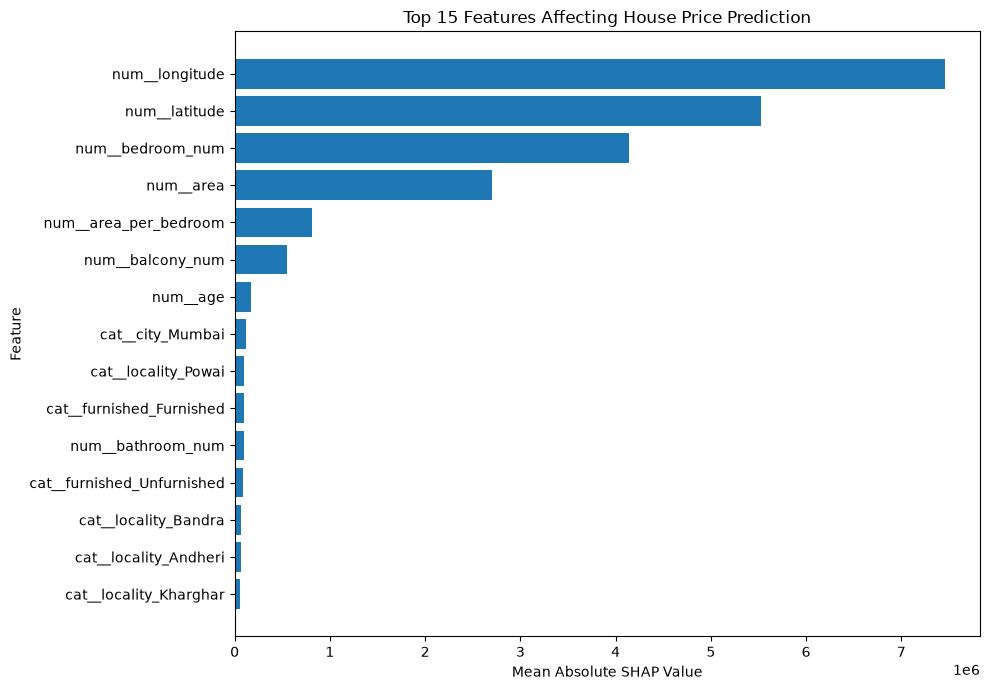

In [20]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_15["feature"][::-1],
    top_15["mean_abs_shap_value"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 Features Affecting House Price Prediction")

plt.tight_layout()
plt.show()

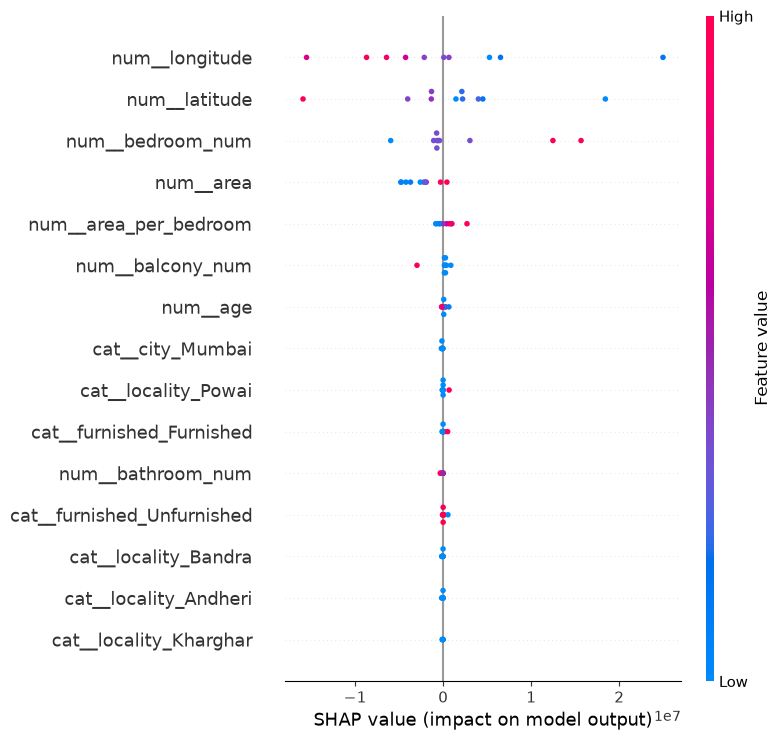

In [21]:
shap.summary_plot(
    shap_values_array,
    X_shap_small,
    feature_names=feature_names,
    max_display=15
)

In [22]:
property_index = 0

selected_property = X_shap_small.iloc[
    property_index
]

print("Selected property:")
display(selected_property)

Selected property:


num__area                        0.948261
num__bedroom_num                 1.065551
num__bathroom_num                1.033975
num__balcony_num                -0.277509
num__age                        -0.541006
                                   ...   
cat__furnished_Unfurnished       1.000000
cat__age_group_Moderately New    0.000000
cat__age_group_New               1.000000
cat__age_group_Old               0.000000
cat__age_group_Very Old          0.000000
Name: 45742, Length: 112, dtype: float64

In [23]:
single_shap_values = shap_values_array[property_index]

individual_explanation = pd.DataFrame({
    "feature": feature_names,
    "shap_value": single_shap_values
})

individual_explanation["absolute_shap_value"] = (
    individual_explanation["shap_value"].abs()
)

individual_explanation = individual_explanation.sort_values(
    "absolute_shap_value",
    ascending=False
).reset_index(drop=True)

display(
    individual_explanation.head(15)
)

,feature,shap_value,absolute_shap_value
0,num__bedroom_num,1.565207e+07,1.565207e+07
1,num__latitude,3.988744e+06,3.988744e+06
2,num__longitude,-2.158846e+06,2.158846e+06
3,num__area_per_bedroom,9.826863e+05,9.826863e+05
4,num__balcony_num,8.634465e+05,8.634465e+05
5,cat__locality_Powai,6.639709e+05,6.639709e+05
6,num__area,-3.106572e+05,3.106572e+05
7,num__bathroom_num,-2.880482e+05,2.880482e+05
8,num__age,2.175834e+05,2.175834e+05
9,cat__city_Mumbai,-2.173929e+05,2.173929e+05


In [24]:
positive_features = individual_explanation[
    individual_explanation["shap_value"] > 0
].head(10)

print("Features contributing positively to prediction:\n")

display(positive_features)

Features contributing positively to prediction:



,feature,shap_value,absolute_shap_value
0,num__bedroom_num,1.565207e+07,1.565207e+07
1,num__latitude,3.988744e+06,3.988744e+06
3,num__area_per_bedroom,9.826863e+05,9.826863e+05
4,num__balcony_num,8.634465e+05,8.634465e+05
5,cat__locality_Powai,6.639709e+05,6.639709e+05
8,num__age,2.175834e+05,2.175834e+05
11,cat__furnished_Unfurnished,9.234923e+04,9.234923e+04
13,cat__locality_Goregaon,5.996654e+04,5.996654e+04
16,cat__furnished_Semi-Furnished,3.589074e+04,3.589074e+04
26,cat__locality_Malad,1.848765e+04,1.848765e+04


In [25]:
negative_features = individual_explanation[
    individual_explanation["shap_value"] < 0
].head(10)

print("Features contributing negatively to prediction:\n")

display(negative_features)

Features contributing negatively to prediction:



,feature,shap_value,absolute_shap_value
2,num__longitude,-2.158846e+06,2.158846e+06
6,num__area,-3.106572e+05,3.106572e+05
7,num__bathroom_num,-2.880482e+05,2.880482e+05
9,cat__city_Mumbai,-2.173929e+05,2.173929e+05
10,cat__furnished_Furnished,-9.821350e+04,9.821350e+04
12,cat__city_Central Mumbai,-7.251381e+04,7.251381e+04
14,cat__locality_Sion,-4.903691e+04,4.903691e+04
15,cat__locality_Bandra,-4.429925e+04,4.429925e+04
17,cat__locality_Ville Parle,-3.454323e+04,3.454323e+04
18,cat__locality_Kharghar,-3.395084e+04,3.395084e+04


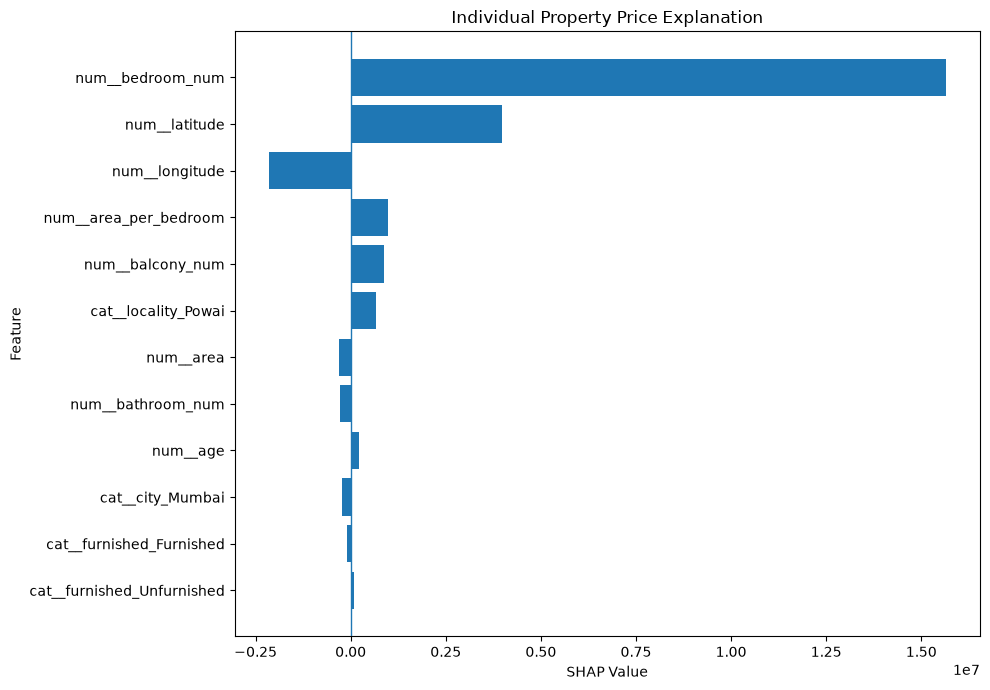

In [26]:
top_individual = individual_explanation.head(12)

plt.figure(figsize=(10, 7))

plt.barh(
    top_individual["feature"][::-1],
    top_individual["shap_value"][::-1]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("Individual Property Price Explanation")

plt.tight_layout()
plt.show()

In [27]:
selected_prediction = model.predict(
    X_shap_small.iloc[[property_index]]
)[0]

print(
    "Predicted Price:",
    selected_prediction
)

Predicted Price: 39421187.844925635


c:\Users\Tejas Dalvi\anaconda3\anaconda\envs\mumbai-house\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [28]:
base_value = explainer.expected_value

print("Base / Expected Model Value:")

if isinstance(base_value, np.ndarray):
    print(base_value[0])
else:
    print(base_value)

Base / Expected Model Value:
20403720.433540914


In [29]:
shap_output_path = (
    "../data/processed/"
    "shap_feature_importance.csv"
)

shap_importance.to_csv(
    shap_output_path,
    index=False
)

print("SHAP feature importance saved successfully")
print(shap_output_path)

SHAP feature importance saved successfully
../data/processed/shap_feature_importance.csv


In [30]:
individual_output_path = (
    "../data/processed/"
    "individual_property_shap_explanation.csv"
)

individual_explanation.to_csv(
    individual_output_path,
    index=False
)

print("Individual SHAP explanation saved successfully")
print(individual_output_path)

Individual SHAP explanation saved successfully
../data/processed/individual_property_shap_explanation.csv


In [31]:
print("=" * 60)
print("SHAP EXPLAINABLE AI COMPLETED")
print("=" * 60)

print("\nModel:")
print(type(model).__name__)

print("\nDataset:")
print(property_data.shape)

print("\nSHAP samples:")
print(X_shap_small.shape)

print("\nNumber of features:")
print(len(feature_names))

print("\nTop 10 Important Features:")

for i, row in shap_importance.head(10).iterrows():
    print(
        f"{i + 1}. {row['feature']} "
        f"-> {row['mean_abs_shap_value']:.4f}"
    )

print("\nSHAP analysis completed successfully.")

SHAP EXPLAINABLE AI COMPLETED

Model:
RandomForestRegressor

Dataset:
(51767, 22)

SHAP samples:
(10, 112)

Number of features:
112

Top 10 Important Features:
1. num__longitude -> 7453347.3889
2. num__latitude -> 5530193.2352
3. num__bedroom_num -> 4139833.4174
4. num__area -> 2706845.4221
5. num__area_per_bedroom -> 812048.0388
6. num__balcony_num -> 554160.8023
7. num__age -> 171197.1192
8. cat__city_Mumbai -> 114521.6323
9. cat__locality_Powai -> 103210.4770
10. cat__furnished_Furnished -> 102285.0664

SHAP analysis completed successfully.
